## Topics
1. [Dependency Parsing](https://spacy.io/usage/linguistic-features/)
2. Extracting dependencies between words.
3. Constituency Parsing
4. Masked Token Prediction using [huggingface pipelines](https://huggingface.co/docs/transformers/main_classes/pipelines#transformers.FillMaskPipeline)
5. Named Entity Recognition (NER)

In [4]:
!pip install benepar
!pip install svgling
!python -m spacy download en_core_web_sm
import logging

import benepar, spacy, nltk
benepar.download('benepar_en3')
nlp = spacy.load('en_core_web_sm')
from spacy import displacy
nlp.add_pipe('benepar', config={'model': 'benepar_en3'})
import warnings
warnings.filterwarnings("ignore", category=UserWarning)
from nltk.tokenize import RegexpTokenizer

## TOKENIZER TO BE USED FOR LAST EXERCISES (KEEPS ONLY WORDS AND REMOVES PUNTS)
tokenizer = RegexpTokenizer(r'\w+')

  Preparing metadata (setup.py) ... done
  Created wheel for benepar: filename=benepar-0.2.0-py3-none-any.whl size=37625 sha256=7a8df03e83cf8be935c9f8ae0baa6a0eeac699137327f085d35aedb67dbcd89e
  Stored in directory: /root/.cache/pip/wheels/9b/84/c1/f2ac877f519e2864e7dfe52a1c17fe5cdd50819cb8d1f1945f
Successfully built benepar
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.1/67.1 kB 3.0 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.8/12.8 MB 68.9 MB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('en_core_web_sm')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


[nltk_data] Downloading package benepar_en3 to /root/nltk_data...
[nltk_data]   Unzipping models/benepar_en3.zip.
You are using the default legacy behaviour of the <class 'transformers.models.t5.tokenization_t5.T5Tokenizer'>. This is expected, and simply means that the `legacy` (previous) behavior will be used so nothing changes for you. If you want to use the new behaviour, set `legacy=False`. This should only be set if you understand what it means, and thoroughly read the reason why this was added as explained in https://github.com/huggingface/transformers/pull/24565


In [5]:
import pandas as pd
import random


## STEPS to get POS tags, dependencies, dependency head with spacy






In [6]:
txt = "This is an example"
txt1_spacy = nlp(txt)
print(type(txt1_spacy), len(txt1_spacy))

for token in txt1_spacy:
  print(token, token.pos_, token.dep_, token.head)

You're using a T5TokenizerFast tokenizer. Please note that with a fast tokenizer, using the `__call__` method is faster than using a method to encode the text followed by a call to the `pad` method to get a padded encoding.


<class 'spacy.tokens.doc.Doc'> 4
This PRON nsubj is
is AUX ROOT is
an DET det example
example NOUN attr is


In [7]:
for token in txt1_spacy:
  print(f"token.head={token.head}({token.head.pos_}), token={token.text}({token.pos_}), dep={token.dep_}", f", DEP: {token.head} -> {token.text}")

token.head=is(AUX), token=This(PRON), dep=nsubj , DEP: is -> This
token.head=is(AUX), token=is(AUX), dep=ROOT , DEP: is -> is
token.head=example(NOUN), token=an(DET), dep=det , DEP: example -> an
token.head=is(AUX), token=example(NOUN), dep=attr , DEP: is -> example


## List of text used in the exercises

In [8]:
corpus = ['the red car stopped abruptly',
          'Alice wore a beautiful dress',
          'Bob played the guitar skillfully',
          'Charlie and David ate a delicious pizza.',
          'Eve sang a lovely song.',
          'Frank read an interesting book.',
          'Grace and Harry watched a scary movie.',
          'Iris painted a colorful picture.',
          'Jack ran a long distance.',
          'Alice and Bob danced gracefully.',
          'Eve wrote a funny story.',
          'Frank cooked a spicy curry.',
          'Charlie and David planted some flowers.',
          'Iris knitted a warm sweater.',
          'Jack built a wooden house.',
          'Alice and Bob traveled to a foreign country.',
          'Eve learned a new language.',
          'Frank taught a math class.',
          'Charlie and David cleaned the messy room.',
          'Iris cut a ripe apple.',
          'Jack drove a fast bike.',
          'Alice and Bob swam in the clear water.',
          'Eve made a chocolate cake.',
          'Frank bought a new phone.',
          'Charlie and David enjoyed the sunny day.']



# Exercise 1
Write a function using spacy that takes doc (i.e. `doc = nlp(text)`) and selects the tokens having the POS tags (NOUN, PROPN, VERB).

In [9]:
# Write a function to extract nouns/pronouns as list from each sentences
def get_noun_list(doc):
  return [token.text.lower() for token in doc if token.pos_ in ['NOUN', 'PROPN', 'VERB']]




# Exercise 2
Extract the token.head and token along with the dependency where

$$ \text{token.head} \in (\text{NOUN}, \text{PROPN}, \text{VERB})$$

AND

$$ \text{token} \in (\text{ADJ}, \text{ADV}) $$

In the form of:

token <-- dep_ <-- token.head

In [25]:
def display_dep(text):
  displacy.render(nlp(text), jupyter=True)

display_dep(corpus[1])

In the above example:

1. red <- amod <- car
2. abruptly <- advmod <- stopped

Should be extracted



In [11]:
# Write a function to extraction dependency relation where head is noun
# and dependency relationship exists with in the form:
#  ADJ_TOKEN (ADJ) <- dep_relation <- NOUN/PRONOUN TOKEN (POS)

def get_noun_direct_rel(text, tail_pos = ['ADJ', 'ADV']):
    fin_rel = []
    doc = nlp(text)
    nouns = get_noun_list(doc)
    for token in doc:
        if token.head.text.lower() in nouns and token.pos_ in tail_pos:
          fin_rel.append(f"{token} <- {token.dep_} <- {token.head}")
    return fin_rel

In [ ]:
get_noun_direct_rel(corpus[1])

# Exercise 3
Apply the extraction function to extract all dependencies from the function implemented above in a list in the form:
```python
[
  [Original_TEXT1, [REL1, REL2, ..]],
  [Original_TEXT2, [REL1, REL2, ..]],
  .
  .
  .
]
```

In [12]:
## Apply the extraction to all the text in corpus. And inspect random examples using p
extracted_patterns = []

for text in corpus:
  rels = get_noun_direct_rel(text)
  extracted_patterns.append([text, rels])

In [13]:
pd.DataFrame(extracted_patterns)

,0,1
0,the red car stopped abruptly,"[red <- amod <- car, abruptly <- advmod <- sto..."
1,Alice wore a beautiful dress,[beautiful <- amod <- dress]
2,Bob played the guitar skillfully,[skillfully <- advmod <- played]
3,Charlie and David ate a delicious pizza.,[delicious <- amod <- pizza]
4,Eve sang a lovely song.,[lovely <- amod <- song]
5,Frank read an interesting book.,[interesting <- amod <- book]
6,Grace and Harry watched a scary movie.,[scary <- amod <- movie]
7,Iris painted a colorful picture.,[colorful <- amod <- picture]
8,Jack ran a long distance.,[long <- amod <- distance]
9,Alice and Bob danced gracefully.,[gracefully <- advmod <- danced]


# Constituency Parsing

In [14]:
def constituency_parse(text):
  doc = nlp(text)
  sent = list(doc.sents)[0]
  return nltk.tree.Tree.fromstring(sent._.parse_string)

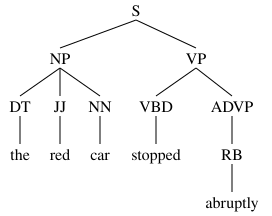

In [15]:
constituency_parse(corpus[0])

In [16]:
# Print the constituency tree for the sentences
sents = ['Alice and Bob swam in the clear water.',
          'Eve made a chocolate cake.',
          'Frank bought a new phone.',
          'Charlie and David enjoyed the sunny day.']

## Exercise 4
Apply constituency paring on `sents` one at a time and observe the difference between constituency paring and dependency parsing.

# MASK PREDICTION USING LANGUAGE MODELS


In [17]:
from transformers import pipeline

fill_masker = pipeline(model="bert-base-uncased")

#eg. of mask filling
fill_masker("This is a simple [MASK].")

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Some weights of the model checkpoint at bert-base-uncased were not used when initializing BertForMaskedLM: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight', 'cls.seq_relationship.bias', 'cls.seq_relationship.weight']
- This IS expected if you are initializing BertForMaskedLM from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForMaskedLM from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Device set to use cpu


[{'score': 0.04227159917354584,
  'token': 3291,
  'token_str': 'problem',
  'sequence': 'this is a simple problem.'},
 {'score': 0.03105006366968155,
  'token': 3160,
  'token_str': 'question',
  'sequence': 'this is a simple question.'},
 {'score': 0.029722517356276512,
  'token': 8522,
  'token_str': 'equation',
  'sequence': 'this is a simple equation.'},
 {'score': 0.026522306725382805,
  'token': 2028,
  'token_str': 'one',
  'sequence': 'this is a simple one.'},
 {'score': 0.024157347157597542,
  'token': 3627,
  'token_str': 'rule',
  'sequence': 'this is a simple rule.'}]

In [26]:
fill_masker("today is [MASK].")

[{'score': 0.05530369654297829,
  'token': 2367,
  'token_str': 'different',
  'sequence': 'today is different.'},
 {'score': 0.024615533649921417,
  'token': 2488,
  'token_str': 'better',
  'sequence': 'today is better.'},
 {'score': 0.021623825654387474,
  'token': 2651,
  'token_str': 'today',
  'sequence': 'today is today.'},
 {'score': 0.020082902163267136,
  'token': 2204,
  'token_str': 'good',
  'sequence': 'today is good.'},
 {'score': 0.017244407907128334,
  'token': 4465,
  'token_str': 'sunday',
  'sequence': 'today is sunday.'}]

# Exercise 5
Write a function that takes a sentence and returns a tuple with a word randomly masked and that word as the second value of the tuple

eg

"I saw a beautiful horse today"--> mask_random(text) --> ("I saw a [MASK] horse today", "beautiful")

In [18]:
import string

def mask_random(text):
  tokens = tokenizer.tokenize(text)
  randval = random.randint(0, len(tokens)-1) # select random token (0, max_index of token)
  original_word = tokens[randval] # save original word
  tokens[randval] = '[MASK]' # replace randval index with '[MASK]'
  return (" ".join(tokens), original_word)

In [19]:
masked_text, original_word = mask_random(corpus[2])
print(masked_text)

[MASK] played the guitar skillfully


In [20]:
# predict masked text
fill_masker(masked_text)

[{'score': 0.5265123248100281,
  'token': 2002,
  'token_str': 'he',
  'sequence': 'he played the guitar skillfully'},
 {'score': 0.07917091995477676,
  'token': 2016,
  'token_str': 'she',
  'sequence': 'she played the guitar skillfully'},
 {'score': 0.0342162549495697,
  'token': 1045,
  'token_str': 'i',
  'sequence': 'i played the guitar skillfully'},
 {'score': 0.005086730699986219,
  'token': 2027,
  'token_str': 'they',
  'sequence': 'they played the guitar skillfully'},
 {'score': 0.0036167597863823175,
  'token': 2198,
  'token_str': 'john',
  'sequence': 'john played the guitar skillfully'}]

## Named Entity Recognition
In this section we will use will use [Huggingface Pipelines]() for Named Entity Recognition.

In [21]:
# Initializing the pipeline for Named Entity Recognition
ner_extractor = pipeline(model="dslim/bert-base-NER", aggregation_strategy="simple")

config.json:   0%|          | 0.00/829 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/433M [00:00<?, ?B/s]

Some weights of the model checkpoint at dslim/bert-base-NER were not used when initializing BertForTokenClassification: ['bert.pooler.dense.bias', 'bert.pooler.dense.weight']
- This IS expected if you are initializing BertForTokenClassification from the checkpoint of a model trained on another task or with another architecture (e.g. initializing a BertForSequenceClassification model from a BertForPreTraining model).
- This IS NOT expected if you are initializing BertForTokenClassification from the checkpoint of a model that you expect to be exactly identical (initializing a BertForSequenceClassification model from a BertForSequenceClassification model).


tokenizer_config.json:   0%|          | 0.00/59.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

added_tokens.json:   0%|          | 0.00/2.00 [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

Device set to use cpu


In [27]:
sent = "the weather in Galway was very pleasant"
ner_extractor(corpus[1])

[{'entity_group': 'PER',
  'score': np.float32(0.9921177),
  'word': 'Alice',
  'start': 0,
  'end': 5}]

# Exercise 6
Implement the following function that takes the sentence and the ner_extractor (i.e. pipeline object) to obtain entity_group (PER, ORG, ...) and the specific words of that category.

In [31]:
def extract_named_entities_from_sentence(sentence, ner_extractor):
   ner_extracted = ner_extractor(sentence)
   return {nerobj['word']: nerobj['entity_group'] for nerobj in ner_extracted}

In [32]:
for sentence in corpus:
  print(f"Sentence      : {sentence}")
  ne_dict = extract_named_entities_from_sentence(sentence, ner_extractor)
  print(f"Named Entities: {ne_dict}")
  print('---------------------')

Sentence      : the red car stopped abruptly
Named Entities: {}
---------------------
Sentence      : Alice wore a beautiful dress
Named Entities: {'Alice': 'PER'}
---------------------
Sentence      : Bob played the guitar skillfully
Named Entities: {'Bob': 'PER'}
---------------------
Sentence      : Charlie and David ate a delicious pizza.
Named Entities: {'Charlie': 'PER', 'David': 'PER'}
---------------------
Sentence      : Eve sang a lovely song.
Named Entities: {'Eve': 'PER'}
---------------------
Sentence      : Frank read an interesting book.
Named Entities: {'Frank': 'PER'}
---------------------
Sentence      : Grace and Harry watched a scary movie.
Named Entities: {'Grace': 'PER', 'Harry': 'PER'}
---------------------
Sentence      : Iris painted a colorful picture.
Named Entities: {'Iris': 'PER'}
---------------------
Sentence      : Jack ran a long distance.
Named Entities: {'Jack': 'PER'}
---------------------
Sentence      : Alice and Bob danced gracefully.
Named Entiti